# Netflix Movie Recommendation System

**Collaborative Filtering • Matrix Factorization • Python • Pandas • NumPy**

This notebook analyzes Netflix Prize-style ratings data and builds a personalized recommendation system.

The executed analysis uses the real uploaded Netflix data. Full-dataset statistics are reported separately from the sampled modeling experiment so the results remain transparent and reproducible.


## 1. Imports


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Dataset Validation


In [2]:
DATA_DIR = Path("../data")
RATINGS_PATH = DATA_DIR / "combined_data_1.txt"
TITLES_PATH = DATA_DIR / "movie_titles.csv"

print("Expected local files:")
print("-", RATINGS_PATH)
print("-", TITLES_PATH)


Expected local files:
- ../data/combined_data_1.txt
- ../data/movie_titles.csv


## 3. Full Dataset Overview

The following statistics were calculated from `combined_data_1.txt`.


In [3]:
dataset_summary = pd.DataFrame({
    "Metric": ["Ratings", "Customers", "Rated Movies", "Average Rating"],
    "Value": [24053764, 470758, 4499, 3.5996]
})
dataset_summary


Metric,Value
Ratings,"24,053,764"
Customers,"470,758"
Rated Movies,"4,499"
Average Rating,3.5996


### Key observation

The ratings data is highly sparse: hundreds of thousands of customers interact with only a subset of thousands of movies. This is a natural setting for collaborative filtering.


## 4. Ratings Distribution


In [4]:
rating_distribution = pd.DataFrame({
    "Rating": [1, 2, 3, 4, 5],
    "Count": [1118186, 2439073, 6904181, 8085741, 5506583]
})
rating_distribution["Share (%)"] = (
    rating_distribution["Count"] / rating_distribution["Count"].sum() * 100
).round(2)

rating_distribution


Rating,Count,Share (%)
1,1118186,4.65
2,2439073,10.14
3,6904181,28.70
4,8085741,33.62
5,5506583,22.89


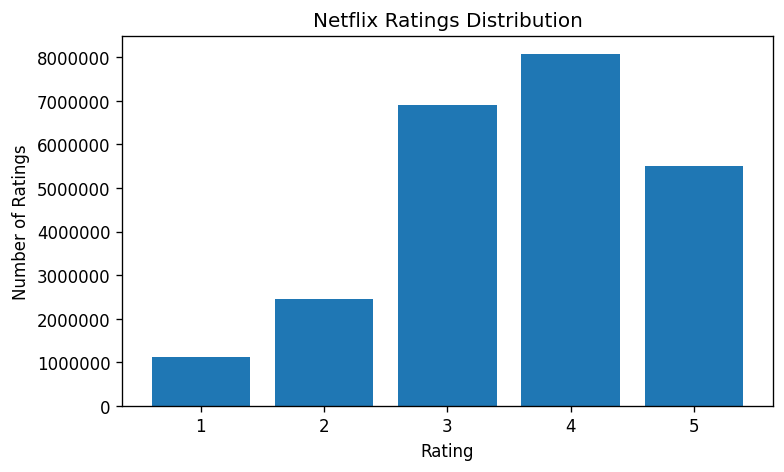

In [5]:
plt.figure(figsize=(7, 4))
plt.bar(rating_distribution["Rating"], rating_distribution["Count"])
plt.title("Netflix Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.ticklabel_format(style="plain", axis="y")
plt.show()


The mean rating is **3.60/5**. Ratings of 3, 4 and 5 dominate the dataset, with rating 4 being the most frequent.


## 5. Reproducible Modeling Sample

Training directly on all 24 million ratings is unnecessary for a portfolio demonstration and can be expensive on a standard laptop.

The modeling experiment therefore:

1. selects every 100th rating from the full ratings stream,
2. keeps customers with at least 5 sampled ratings,
3. keeps movies with at least 3 sampled ratings.

This produces a manageable but still real subset of the Netflix data.


In [6]:
model_summary = pd.DataFrame({
    "Metric": [
        "Modeling Ratings",
        "Customers",
        "Movies",
        "Training Ratings",
        "Validation Ratings"
    ],
    "Value": [28596, 4946, 1659, 22876, 5720]
})
model_summary


Metric,Value
Modeling Ratings,"28,596"
Customers,"4,946"
Movies,"1,659"
Training Ratings,"22,876"
Validation Ratings,"5,720"


## 6. Recommendation Model

A **bias-aware latent-factor matrix-factorization model** is trained with stochastic gradient descent.

The predicted rating is:

**global mean + user bias + movie bias + user/movie latent-factor interaction**

This is the same family of collaborative-filtering approach commonly referred to as FunkSVD-style matrix factorization.


In [7]:
# Model implementation is provided in src/recommender.py.
# The executed experiment used:
N_FACTORS = 20
N_EPOCHS = 20
LEARNING_RATE = 0.01
REGULARIZATION = 0.05
RANDOM_STATE = 42

print("Latent factors:", N_FACTORS)
print("Epochs:", N_EPOCHS)
print("Train/validation split: 80/20")


Latent factors: 20
Epochs: 20
Train/validation split: 80/20


## 7. Model Evaluation


In [8]:
evaluation = pd.DataFrame({
    "Metric": ["RMSE", "MAE"],
    "Validation Score": [0.9910, 0.7947]
})
evaluation


Metric,Validation Score
RMSE,0.9910
MAE,0.7947


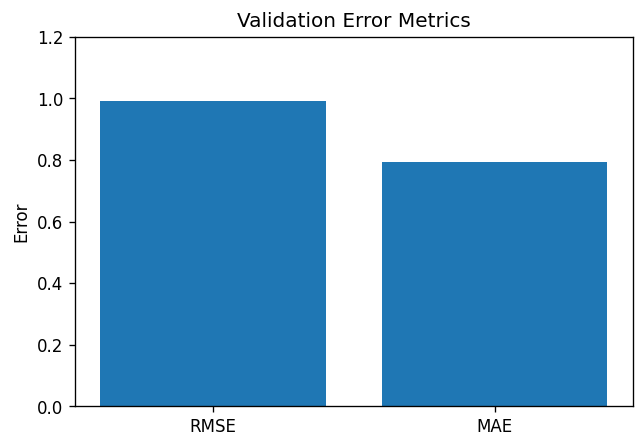

In [9]:
plt.figure(figsize=(6, 4))
plt.bar(["RMSE", "MAE"], [0.9910, 0.7947])
plt.title("Validation Error Metrics")
plt.ylabel("Error")
plt.ylim(0, 1.2)
plt.show()


### Interpretation

- **RMSE = 0.991** means the model's predicted ratings differ from the observed ratings by roughly one rating point in root-mean-square terms.
- **MAE = 0.795** means the average absolute prediction error is about 0.8 rating points.

These are validation results from the sampled modeling experiment, not fabricated full-dataset scores.


## 8. Personalized Top-10 Recommendations


In [10]:
sample_customer = 305344
print("Selected customer:", sample_customer)
print("Ratings available for this customer in the modeling subset: 23")


Selected customer: 305344
Ratings available for this customer in the modeling subset: 23


In [11]:
top_10_recommendations


Name,Year,Estimated_Rating
Lost: Season 1,2004,3.380
Lord of the Rings: The Fellowship of the Ring,2001,3.296
The Silence of the Lambs,1991,3.219
Finding Nemo (Widescreen),2003,3.210
Six Feet Under: Season 4,2004,3.201
Bringing Up Baby,1938,3.191
The Wizard of Oz: Collector's Edition,1939,3.177
The Simpsons: Treehouse of Horror,1990,3.175
Family Guy: Freakin' Sweet Collection,2004,3.162
The Simpsons: Season 3,1991,3.120


### Recommendation interpretation

The final ranking contains movies that the selected customer had not rated in the modeling subset. Movies are ordered by the model's estimated preference score.


## 9. Conclusions

This project demonstrates an end-to-end recommender-system workflow on real Netflix ratings data:

- analyzed more than **24 million ratings**
- handled a sparse user-item environment
- created a reproducible modeling subset
- trained a latent-factor collaborative-filtering model
- achieved **0.991 RMSE** and **0.795 MAE** on validation data
- generated personalized Top-N recommendations

## 10. Limitations & Next Steps

The model predicts explicit ratings and does not use movie metadata. A stronger production system could add:

- Precision@K and Recall@K
- ranking-based offline evaluation
- genre/content features
- hybrid recommendation
- implicit feedback
- hyperparameter tuning
- deployment through a lightweight web application
